In [1]:
import re
import numpy as np
from numpy.linalg import norm, svd
np.random.seed(99)
import random
from matplotlib import pyplot
%matplotlib inline
import sklearn.datasets
from sklearn import preprocessing
from sklearn import svm
from sklearn.decomposition import PCA
import time
import sys

# Task 1: Face Recognition on YaleB

## Data loading

### Remember to do the data-preprocessing step in the pdf file

In [2]:
# I use the code snippet from https://stackoverflow.com/questions/7368739/numpy-and-16-bit-pgm/7369986
# It read PGM image buffer string and return a numpy array
def read_pgm2(buffer, byteorder='>'):
    """Return image data from a raw PGM file as numpy array.
    Format specification: http://netpbm.sourceforge.net/doc/pgm.html
    """
    #with open(filename, 'rb') as f:
    #    buffer = f.read()
    try:
        #print ("buffer", buffer)
        header, width, height, maxval = re.search(
            b"(^P5\s(?:\s*#.*[\r\n])*"
            b"(\d+)\s(?:\s*#.*[\r\n])*"
            b"(\d+)\s(?:\s*#.*[\r\n])*"
            b"(\d+)\s(?:\s*#.*[\r\n]\s)*)", buffer).groups()
    except AttributeError:
        return None
        #raise ValueError("Not a raw PGM file: '%s'" % buffer)
    #print 'width',width, 'height', height
    
    return np.frombuffer(buffer,
                            dtype='u1' if int(maxval) < 256 else byteorder+'u2',
                            count=int(width)*int(height),
                            offset=15#len(header)
                            ).reshape((int(height), int(width)))

In [3]:
dataset0 = sklearn.datasets.load_files("CroppedYale", shuffle=True)

In [4]:
print (dir(dataset0))

['DESCR', 'data', 'filenames', 'target', 'target_names']


CroppedYale/yaleB11/yaleB11_P00A-035E+15.pgm
10
yaleB11
1280


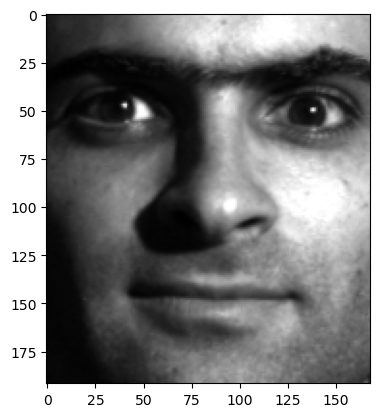

In [5]:
idx0 = len(dataset0.filenames)-1
print (dataset0.filenames[idx0])
print (dataset0.target[idx0])
print (dataset0.target_names[dataset0.target[idx0]])
print (len(dataset0.filenames))
image0 = read_pgm2(dataset0.data[idx0])
pyplot.imshow(image0, pyplot.cm.gray)

In [6]:
len(dataset0.filenames)

1280

In [7]:
len(dataset0.data)

1280

In [8]:
size0 = 320
separate = int(size0*0.8)
y = dataset0.target

X_lst = []
y_lst = []

for i in range(len(dataset0.data)):
    X_ret = read_pgm2(dataset0.data[i])
    y_ret = y[i]
    if X_ret is not None:
        if X_ret.shape == (192, 168):
            X_lst.append(X_ret)
            y_lst.append(y_ret)

X = np.stack(X_lst)
X = X[:size0]

shapeX = X.shape
X = X.reshape((shapeX[0],shapeX[1]*shapeX[2]))
X = preprocessing.scale(X.astype(float),axis=1) # Mean removal and variance scaling

y = np.stack(y_lst)

y = y[:size0]
#imageX = X[0].reshape((shapeX[1],shapeX[2]))
#pyplot.imshow(imageX, pyplot.cm.gray)

print (X.shape, y.shape)

X_train = X[:separate]
y_train = y[:separate]
X_test = X[separate:]
y_test = y[separate:]

print (y_test[:10])
print(X_train.shape)
print(X.shape)

(320, 32256) (320,)
[ 4  4 14  7  4  3 17  7  1 10]
(256, 32256)
(320, 32256)


## Task 1.1: Classify with OvA SVM directly

In [9]:
clf = svm.LinearSVC(penalty='l1', dual = False)
#had to change penalty('l1') to this because penalty l1 is incompatible with squared hinge loss (default loss when unspecified) when dual = True)

start_train = time.time()
clf.fit(X_train, y_train) #fit = Iteratively update weights to: reduce misclassification error, and in this case push small weights to zero (L1 pressure)
end_train = time.time()
print ("Time elapsed for training the SVM:", end_train - start_train, "s")

Time elapsed for training the SVM: 4.3816516399383545 s


/opt/conda/lib/python3.11/site-packages/sklearn/svm/_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


In [10]:
pred = clf.predict(X_test[:10])
print ('True labels:', y_test[:10])
print ('Predicted:  ', pred)
score_te = clf.score(X_test, y_test)
print ("Test accuracy:", score_te)

True labels: [ 4  4 14  7  4  3 17  7  1 10]
Predicted:   [ 4  4 14  7  4 13 13  7  1 10]
Test accuracy: 0.828125


## Task 1.2: Classify after PCA

In [11]:
#fit PCA on training data. then apply PCA transofmration on the test set
pca = PCA(n_components = 150)

start_train = time.time()
X_train_reduced = pca.fit_transform(X_train) #reduces shape from (256, 32256) to (256, 150)
end_train = time.time()
print ("Time elapsed for PCA:", end_train - start_train, "s")
X_test_reduced = pca.transform(X_test) #fit on training data only. on test data only transform

Time elapsed for PCA: 7.899897575378418 s


In [12]:
#perform a second SVM after PCA
clf2 = svm.LinearSVC(penalty = 'l1', dual = False)  # (remember set penalty='l1')
start_train = time.time()
clf2.fit(X_train_reduced, y_train)
end_train = time.time()
print ("Time elapsed for training the SVM2:", end_train - start_train, "s")

Time elapsed for training the SVM2: 1.4772005081176758 s


/opt/conda/lib/python3.11/site-packages/sklearn/svm/_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


In [13]:
pred2 = clf2.predict(X_test_reduced[:10]) #looking at a sample of 10 predictions
print ('True labels:', y_test[:10])
print ('Predicted:  ', pred2)
score_te2 = clf2.score(X_test_reduced, y_test) ##clf2.score computes clf2.predict(X_test)inside of it, and returns the test accuracy for all test samples
print ("Test accuracy:", score_te2)

True labels: [ 4  4 14  7  4  3 17  7  1 10]
Predicted:   [ 4  4 14  7  4 13 19  7  1 10]
Test accuracy: 0.875


## Task 1.3: Classify after robust PCA (via inexact ALM)

In [9]:
# http://kastnerkyle.github.io/posts/robust-matrix-decomposition/

def inexact_augmented_lagrange_multiplier(X, lmbda=.01, tol=1e-3,
                                          maxiter=100, verbose=True):
    """
    Inexact Augmented Lagrange Multiplier
    """
    Y = X
    norm_two = norm(Y.ravel(), 2)
    norm_inf = norm(Y.ravel(), np.inf) / lmbda
    dual_norm = np.max([norm_two, norm_inf])
    Y = Y / dual_norm
    A = np.zeros(Y.shape)
    E = np.zeros(Y.shape)
    dnorm = norm(X, 'fro')
    mu = 1.25 / norm_two
    rho = 1.5
    sv = 10.
    n = Y.shape[0]
    itr = 0
    while True:
        Eraw = X - A + (1 / mu) * Y
        Eupdate = np.maximum(Eraw - lmbda / mu, 0) + np.minimum(Eraw + lmbda / mu, 0)
        U, S, V = svd(X - Eupdate + (1 / mu) * Y, full_matrices=False)
        svp = (S > 1 / mu).shape[0]
        if svp < sv:
            sv = np.min([svp + 1, n])
        else:
            sv = np.min([svp + round(.05 * n), n])
        Aupdate = np.dot(np.dot(U[:, :svp], np.diag(S[:svp] - 1 / mu)), V[:svp, :])
        A = Aupdate
        E = Eupdate
        Z = X - A - E
        Y = Y + mu * Z
        mu = np.min([mu * rho, mu * 1e7])
        itr += 1
        if ((norm(Z, 'fro') / dnorm) < tol) or (itr >= maxiter):
            break
    if verbose:
        print("Finished at iteration %d" % (itr))  
    return A, E

In [15]:
start_train = time.time()
A, E = inexact_augmented_lagrange_multiplier(X_train) 
#RPCA separates training data into A + E where A captures the main features, and E is the noise (think sunglasses, shadows) that we don't want to be fed into PCA
end_train = time.time()
print ("Time elapsed for robust PCA:", end_train - start_train, "s")

Finished at iteration 16
Time elapsed for robust PCA: 834.2621676921844 s


In [16]:
start_train = time.time()
# Only specify svd_solver for this sub-task. Use PCA(n_components=150) for other tasks
pca2 = PCA(n_components=150, svd_solver='full') 

pca2.fit(A) #this does "learn from clean faces". it creates a new basis of components- A is used to decide the important directions to describe clean faces (without sunglasses etc).
end_train = time.time()
print ("Time elapsed for extracting new basis:", end_train - start_train, "s")

Time elapsed for extracting new basis: 43.09772706031799 s


In [17]:
#Express the original training faces using the 'clean face directions'
X_train_reduced2 = pca2.transform(X_train) #PCA transform the training data using the basis from A
X_test_reduced2 = pca2.transform(X_test)

In [18]:
clf3 = svm.LinearSVC(penalty = 'l1', dual = False)#(remember set penalty='l1')
start_train = time.time()
clf3.fit(X_train_reduced2, y_train)
end_train = time.time()
print ("Time elapsed for training the SVM3:", end_train - start_train, "s")

Time elapsed for training the SVM3: 1.2836692333221436 s


/opt/conda/lib/python3.11/site-packages/sklearn/svm/_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


In [19]:
pred3 = clf3.predict(X_test_reduced2[:10])
print ('True labels:', y_test[:10])
print ('Predicted:  ', pred3)
score_te3 = clf3.score(X_test_reduced2, y_test)
print ("Test accuracy:", score_te3)

True labels: [ 4  4 14  7  4  3 17  7  1 10]
Predicted:   [ 4  4 14  7  4  5 19  7  1 10]
Test accuracy: 0.875


Comparing the Pros and Cons of PCA and robust PCA

The pros of PCA are that it allows high dimensional data to be represented in lower dimensions which can speed up efficiency in machine learning, and also makes it so that data can be visualized, such as taking an n dimensional dataset into a 3D or 2D space to graph it. It is good at representing clean data with little noise.
A pro is that for this assignment, performing PCA before SVM improved test accuracy by almost 5%.

A con of PCA is that if there is a lot of noise, such as faces that have shadows or sunglasses, the representation is easily affected, because noise contributes significantly to variance (dark shadows or sunglasses are very different from the rest of the faces because of shading and shape).
The pros of robust PCA are that in the presence of noise, it is robust and able to accurately represent data without the noise taking over. It can be used to identify the presence of people in a scene, or for anomaly detection. A con of robust PCA is that it takes much longer to implement. Also, in this case, there was no improvement in test accuracy when comparing PCA and robust PCA.

# Task 2: Recognition on Occluded YaleB

320
range(0, 175)


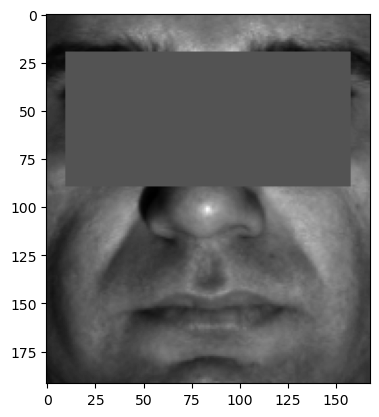

In [10]:
X_or = X.reshape((shapeX[0],192,168))


X_cp = np.copy(X_or)
print (len(X_cp))

def random_occlusion(X):
    N = len(X)
    rnd_occ = range(175)

    print (rnd_occ)
    for i in rnd_occ:
        X[i][20:90,10:-10] = 0
random_occlusion(X_cp)

pyplot.imshow(X_cp[3], pyplot.cm.gray)
pyplot.imshow(X_cp[4], pyplot.cm.gray)

In [11]:
size0 = 320
separate = int(size0*0.8)
X = X_cp[:size0]

shapeX = X.shape
X = X.reshape((shapeX[0],shapeX[1]*shapeX[2]))
X = preprocessing.scale(X.astype(float),axis=1) # Mean removal and variance scaling

print (X.shape, y.shape)

X_train = X[:separate]
y_train = y[:separate]
X_test = X[separate:]
y_test = y[separate:]

print (y_test[:10])

(320, 32256) (320,)
[ 4  4 14  7  4  3 17  7  1 10]


## Task 2.1: Classify with OvA SVM directly

In [13]:
clf = svm.LinearSVC(penalty='l1', dual = False) ###### (the #### denote where I had to fill in code from the given skeleton)

start_train = time.time()
clf.fit(X_train, y_train)###### 
end_train = time.time()
print ("Time elapsed for training the SVM:", end_train - start_train, "s")

Time elapsed for training the SVM: 3.209702253341675 s


/opt/conda/lib/python3.11/site-packages/sklearn/svm/_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


In [14]:
pred = clf.predict(X_test[:10])
print ('True labels:', y_test[:10])
print ('Predicted:  ', pred)
score_te = clf.score(X_test, y_test) ###### 
print ("Test accuracy:", score_te)

True labels: [ 4  4 14  7  4  3 17  7  1 10]
Predicted:   [ 4  4 14  5  4  5 13  7  1 10]
Test accuracy: 0.796875


## Task 2.2: Classify after PCA

In [15]:
pca = PCA(n_components = 150) ###### 

start_train = time.time()
X_train_reduced = pca.fit_transform(X_train) ######
end_train = time.time()
print ("Time elapsed for PCA:", end_train - start_train, "s")
X_test_reduced =  pca.transform(X_test) ######

Time elapsed for PCA: 7.432229995727539 s


In [16]:
clf2 = svm.LinearSVC(penalty = 'l1', dual = False) ###### 
start_train = time.time()
clf2.fit(X_train_reduced, y_train) ######
end_train = time.time()
print ("Time elapsed for training the SVM2:", end_train - start_train, "s")

Time elapsed for training the SVM2: 1.1230113506317139 s


/opt/conda/lib/python3.11/site-packages/sklearn/svm/_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


In [17]:
pred2 = clf2.predict(X_test_reduced[:10])
print ('True labels:', y_test[:10])
print ('Predicted:  ', pred2)
score_te2 = clf2.score(X_test_reduced, y_test) #####
print ("Test accuracy:", score_te2)

True labels: [ 4  4 14  7  4  3 17  7  1 10]
Predicted:   [ 4  4 14  7  4 13 19  7  1 10]
Test accuracy: 0.828125


## Task 2.3: Classify after robust PCA (via inexact ALM)

In [12]:
start_train = time.time()
A, E = inexact_augmented_lagrange_multiplier(X_train) ####
end_train = time.time()
print ("Time elapsed for robust PCA:", end_train - start_train, "s")

Finished at iteration 17
Time elapsed for robust PCA: 874.2158062458038 s


In [18]:
start_train = time.time()
pca2 = PCA(n_components = 150) ######
pca2.fit(A) ####### 
end_train = time.time()
print ("Time elapsed for extracting new basis:", end_train - start_train, "s")

Time elapsed for extracting new basis: 8.43181562423706 s


In [19]:
X_train_reduced2 = pca2.transform(X_train)
X_test_reduced2 = pca2.transform(X_test)

In [20]:
clf3 = svm.LinearSVC(penalty = 'l1', dual = False) ###### (remember set penalty='l1')
start_train = time.time()
clf3.fit(X_train_reduced2, y_train) ###### 
end_train = time.time()
print ("Time elapsed for training the SVM3:", end_train - start_train, "s")

Time elapsed for training the SVM3: 1.1052577495574951 s


/opt/conda/lib/python3.11/site-packages/sklearn/svm/_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


In [21]:
pred3 = clf3.predict(X_test_reduced2[:10])
print ('True labels:', y_test[:10])
print ('Predicted:  ', pred3)
score_te3 = clf3.score(X_test_reduced2, y_test)###### 
print ("Test accuracy:", score_te3)

True labels: [ 4  4 14  7  4  3 17  7  1 10]
Predicted:   [ 4  4 14  7  4  3 19  7  1 10]
Test accuracy: 0.875


On the partially occluded dataset, a pro of PCA is that it increased test accuracy from 79.7% without it to 82.3% with it. A con is that PCA on the partially occluded dataset did not result in as high of a test accuracy than PCA on the nonoccluded dataset (82.3% compared to 87.5%). This is expected due to how PCA is known to be influenced by the presence of noise. A pro of robust PCA is that since it accounts for noise, such as the occlusion of the eyes, it produced a higher test accuracy of 87.5%, compared to 82.3% with PCA.

**Bonus** Without changing the n components parameter of all
PCA, can you improve the accuracy of the third subtask, which is a combination
of RPCA-PCA-SVM? How about combining the low rank matrix A and the
sparse error matrix E and fit the PCA on the combined data?


In [46]:
A_and_E = A + 0.2 * E

pca3 = PCA(n_components = 150)
pca3.fit(A_and_E)

X_train_reduced2_E = pca3.transform(X_train)
X_test_reduced2_E = pca3.transform(X_test)

clf4 = svm.LinearSVC(penalty = 'l1', dual = False)
clf4.fit (X_train_reduced2_E, y_train)

test_accuracy = clf4.score(X_test_reduced2_E, y_test)
print(test_accuracy)

0.90625


/opt/conda/lib/python3.11/site-packages/sklearn/svm/_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


I combined the low rank matrix A and the sparse error matrix E using a weighted combination, where the weight is a hyperparameter that affects how much the sparse error matrix will influence PCA. (0 is not at all, as was the case above where pca was fit on A. 1 would result in X = A + E: the original X). 
Using `A + 0.2 * E` achieved a higher accuracy of 90.6%.